In [5]:
%cd ..

d:\github\ssd


In [6]:
from typing import List
import cv2
import torch
import numpy as np
import torch.nn.functional as F

from model.ssd import SSD
from config import load_config_from_yaml
from utils import nms, decode_offsets_to_boxes, visualize_bboxes

In [ ]:
model_config = load_config_from_yaml(
    config_type='model',
    file_path='./configs/model/ssd300.yaml'
)

data_config = load_config_from_yaml(
    config_type='data',
    file_path='./configs/data/voc.yaml'
)

In [ ]:
model = SSD(model_config)
state_dict = torch.load('./weights/best.pt')
model.load_state_dict(state_dict)
model.eval()

SSD(
  (backbone): VGGBackbone(
    (layers): ModuleList(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (

In [9]:
image = cv2.imread('./sample/test.jpg', cv2.IMREAD_COLOR)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

x = cv2.resize(image, (300, 300)).astype(np.float32)
x -= (104.0, 117.0, 123.0)
x = x.astype(np.float32)
x = x[:, :, ::-1].copy()
x = torch.from_numpy(x).permute(2, 0, 1)
x = x.unsqueeze(0)
loc, conf, default_boxes = model(x)

In [10]:
def ssd_inference(
    loc: torch.Tensor,
    conf: torch.Tensor,
    default_boxes: torch.Tensor,
    num_classes: int,
    background_label: int,
    top_k: int,
    conf_threshold: float,
    iou_threshold: float,
    box_variances: List[float],
) -> torch.Tensor:
    
    loc, conf, default_boxes = loc.detach(), conf.detach(), default_boxes.detach() 
    conf = F.softmax(conf, dim=-1)
    
    batch_size = loc.size(0)
    conf_preds = conf.transpose(2, 1)
    output = torch.zeros(batch_size, num_classes, top_k, 5, device=loc.device)

    for b in range(batch_size):
        decoded_boxes = decode_offsets_to_boxes(loc[b], default_boxes, box_variances)
        scores_per_class = conf_preds[b]

        for cls_id in range(num_classes):
            if cls_id == background_label:
                continue

            scores = scores_per_class[cls_id]
            mask = scores > conf_threshold

            if mask.sum() == 0:
                continue

            cls_scores = scores[mask]
            cls_boxes = decoded_boxes[mask]

            indices, count = nms(
                boxes=cls_boxes,
                scores=cls_scores,
                overlap=iou_threshold,
                top_k=top_k,
            )

            keep = indices[:count]
            output[b, cls_id, :count] = torch.cat(
                [cls_scores[keep].unsqueeze(1), cls_boxes[keep]],
                dim=1,
            )

    return output

In [ ]:
results = ssd_inference(
    loc=loc,
    conf=conf,
    default_boxes=default_boxes,
    num_classes=21,
    background_label=data_config.background_label,
    top_k=200,
    conf_threshold=0.6,
    iou_threshold=0.45,
    box_variances=model_config.box_variances
)

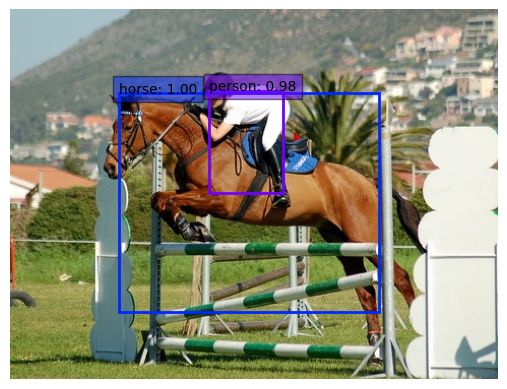

In [12]:
visualize_bboxes(
    rgb_image=rgb_image,
    bboxes=results,
    labels=data_config.labels,
    conf_threshold=0.6
)